<br>
<p float="right">
  <img src=attachment:nanoHUB_logo_color.png width="25%" height='10%' align="right" /> 
</p>

# Demonstration: LAMMPS Parser on LLM-Automatic Script Generation

### <i>Ethan Holbrook, Juan C. Verduzco, </i>  and <i>Alejandro Strachan </i>
### Materials Engineering, Purdue University <br>

This notebook aggregates results from the generation, parsing, execution, and accuracy stages to produce summary tables and Sankey-style visualizations of pipeline outcomes.

Its purpose is to show how scripts progress through successive evaluation filters, including normalization, parsing, execution, and final accuracy. The figures and tables here are intended for interpretation and reporting rather than for generating new benchmark data.

## Tips
1. Found a bug? Email holbrooe@purdue.edu

<br><br><br>

# Pipeline Summary and Visualization




In [2]:
import os
import json
import sys
import shutil
import re

from dotenv import load_dotenv
load_dotenv()

from lark import tree
from lammps_ast.sanitizer import sanitize
from lammps_ast.parser import parse_to_AST

import lammps_ast
print(dir(lammps_ast))
print(lammps_ast.__path__)

import openai
from openai import OpenAI

import numpy as np
import pandas as pd

import subprocess

from colorama import Fore, Style

from importlib.metadata import version
print(version("lammps-ast"))

# import anthropic
import plotly.graph_objects as go

import ast # python

['__author__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'error_handler', 'grammar', 'parse_to_AST', 'parser', 'sanitize', 'sanitizer', 'transformer']
['/home/holbrooe/.conda/envs/2022.10-py39/gst/lib/python3.12/site-packages/lammps_ast']
0.1.7


In [3]:
def compute_accuracy_metrics(accuracy_df, *, verbose: bool = False):
    """
    Compute pipeline metrics with safe handling for missing categories/columns.
    Mirrors your replacement logic while avoiding bare try/except and KeyErrors.
    """

    def vc_get(series, key):
        # Safe value_counts() lookup
        return series.value_counts(dropna=False).get(key, 0)

    total_scripts = int(len(accuracy_df))

    # --- Sanitizer ---
    sanitizer_to_parser = vc_get(accuracy_df['sanitized'], True)
    sanitizer_to_failure = total_scripts - sanitizer_to_parser

    # --- Parser ---
    parser_to_execution = vc_get(accuracy_df['parsed'], True)
    # "failed parser" = everything not True minus those that failed sanitizer
    parser_to_failure = total_scripts - parser_to_execution - int((accuracy_df['sanitized'] != True).sum())

    if verbose:
        print('Total_scripts: ', total_scripts)
        print('Parsed Success: ', parser_to_execution)
        print('Failed Sanitizer: ', int((accuracy_df['sanitized'] != True).sum()))

    # --- Execution (primary run) ---
    execution_to_accuracy = vc_get(accuracy_df['run'], True)
#     execution_to_pairstylecheck = accuracy_df['run'].astype(str).str.startswith("Last command:").sum() #### old style
    execution_to_pairstylecheck = 0
    for row in accuracy_df["run"]:
        if row != True and row != 'not parsed':
    #         print(row)
            if ast.literal_eval(row)[1].startswith("Last command:"):
                execution_to_pairstylecheck += 1
    # --- Pair-style re-run path (optional column) ---
    pair_run_col = 'pair_run'
    if pair_run_col in accuracy_df.columns:
        pairstylecheck_to_execution = vc_get(accuracy_df[pair_run_col], True)
        execution_to_accuracy_after_pairstyle = vc_get(accuracy_df[pair_run_col], True)
        pair_df = accuracy_df[accuracy_df[pair_run_col] == True].copy()
    else:
        pairstylecheck_to_execution = 0
        execution_to_accuracy_after_pairstyle = 0
        pair_df = accuracy_df.iloc[0:0].copy()  # empty

    # Total execution failures = everything not accounted for by success paths
    execution_to_failure = (
        total_scripts
        - execution_to_accuracy
        - execution_to_accuracy_after_pairstyle
        - parser_to_failure
    )

    # --- Accuracy results (primary run) ---
    if 'accurate' in accuracy_df.columns:
        accuracy_to_correct = vc_get(
            accuracy_df.loc[accuracy_df['run'] == True, 'accurate'],
            True
        )
    else:
        accuracy_to_correct = 0

    accuracy_to_failure = execution_to_accuracy - accuracy_to_correct

    # --- Pair accuracy with allowed-token filter ---
    # Count rows where `accurate` includes ONLY tokens from allowed set.
    # Anything else = failure.
#     allowed = {"pair_style", "run_trial", "size10_conflict"} old style
    allowed = {"PSZ", "pair_style inaccurate"}
    
    if not pair_df.empty and 'accurate' in pair_df.columns:
        col = pair_df['accurate'].astype(str)
        mask_has_disallowed = col.apply(
            lambda s: any(tok not in allowed for tok in map(str.strip, s.split(",")) if tok.strip())
        )
        pair_to_accuracy_total = int(len(pair_df))
        pair_accuracy_to_failure = int(mask_has_disallowed.sum())
        pair_accuracy_to_correct = pair_to_accuracy_total - pair_accuracy_to_failure
    else:
        pair_accuracy_to_failure = 0
        pair_accuracy_to_correct = 0

    if verbose:
        print('Total pair Success:', int(len(pair_df)))
        print('Accurate Pair Correct: ', pair_accuracy_to_correct)
        print('Accurate Pair Failure: ', pair_accuracy_to_failure)

    return {
        "total_scripts": total_scripts,
        "sanitizer_to_parser": int(sanitizer_to_parser),
        "sanitizer_to_failure": int(sanitizer_to_failure),
        "parser_to_execution": int(parser_to_execution),
        "parser_to_failure": int(parser_to_failure),
        "execution_to_accuracy": int(execution_to_accuracy),
        "execution_to_pairstylecheck": int(execution_to_pairstylecheck),
        "pairstylecheck_to_execution": int(pairstylecheck_to_execution),
        "execution_to_accuracy_after_pairstyle": int(execution_to_accuracy_after_pairstyle),
        "execution_to_failure": int(execution_to_failure),
        "accuracy_to_correct": int(accuracy_to_correct),
        "accuracy_to_failure": int(accuracy_to_failure),
        "pair_accuracy_to_correct": int(pair_accuracy_to_correct),
    }


In [4]:
import pandas as pd

# Columns your metrics function needs
EXPECTED_COLS = ["sanitized", "parsed", "run", "pair_run", "accurate"]

def get_accuracy_df(prompt: str,
                    model: str,
                    master_df: pd.DataFrame,
                    prompt_model_map: dict[str, list[str]]) -> pd.DataFrame:
    """
    Return the per-combo accuracy_df for (prompt, model) by filtering master_df.
    Validates the combo against the provided prompt_model_map and ensures
    required columns exist.
    """
    # --- Validate the combo against the 12 allowed combos ---
    if prompt not in prompt_model_map:
        raise ValueError(
            f"Unknown prompt '{prompt}'. "
            f"Known prompts: {list(prompt_model_map.keys())}"
        )
    if model not in prompt_model_map[prompt]:
        raise ValueError(
            f"Model '{model}' not in prompt_model_map['{prompt}'].\n"
            f"Allowed models for {prompt}: {prompt_model_map[prompt]}"
        )

    # --- Validate required columns in master_df ---
    required_in_master = set(EXPECTED_COLS + ["prompt", "model"])
    missing = required_in_master - set(master_df.columns)
    if missing:
        raise KeyError(
            f"master_df is missing required columns: {sorted(missing)}\n"
            f"Expected at least: {sorted(required_in_master)}"
        )

    # --- Filter to the specific prompt/model combo ---
    mask = (master_df["prompt"] == prompt) & (master_df["model"] == model)
    df = master_df.loc[mask, EXPECTED_COLS].copy()

    if df.empty:
        # Helpful diagnostics
        available_counts = (
            master_df.groupby(["prompt", "model"])
                     .size()
                     .sort_values(ascending=False)
                     .head(12)
        )
        raise ValueError(
            f"No rows found for combo ({prompt}, {model}). "
            f"Top available (prompt, model) pairs with counts:\n{available_counts}"
        )

    return df


In [5]:
# accuracy_df.to_pickle('sample_claude.pkl')
# data = '150_scripts_5_models_sani.pkl'
data = 'accuracy_df_trees.pkl'
# accuracy_df = pd.read_pickle(f'../../lammps_parser_clone/bin/{data}')
accuracy_df = pd.read_pickle(data)
pd.set_option('display.max_rows', None) 

display(accuracy_df)

,prompt,model,trial,sanitized,parsed,ast_path,run,pair_run,accurate
0,prompt1,gpt-4o,0,True,True,asts/prompt1/gpt-4o/prompt1-gpt-4o-T0.ast.pkl,True,n/a,True
1,prompt2,gpt-4o,0,True,True,asts/prompt2/gpt-4o/prompt2-gpt-4o-T0.ast.pkl,['ERROR: Incorrect args for pair coefficients ...,[Errno 2] No such file or directory: '/apps/sh...,"pair_style inaccurate, size"
2,prompt3,gpt-4o,0,True,True,asts/prompt3/gpt-4o/prompt3-gpt-4o-T0.ast.pkl,['ERROR: Incorrect args for pair coefficients ...,[Errno 2] No such file or directory: '/apps/sh...,"box_region_missing, fixed bounds, gap_size, pa..."


In [6]:
accuracy_df[accuracy_df['model']=='claude-4-opus-20250514']

,prompt,model,trial,sanitized,parsed,ast_path,run,pair_run,accurate


In [7]:
error_counts = (
    accuracy_df["accurate"]
      .dropna()                     # optional, ignore NaNs
      .str.split(",")               # -> list of errors
      .explode()                    # one error per row
      .str.strip()                  # remove surrounding spaces
      .value_counts()               # frequency counts
)

print(error_counts)
print(error_counts/150*100)

accurate
pair_style inaccurate     2
size                      1
box_region_missing        1
fixed bounds              1
gap_size                  1
projectile_region_size    1
run num inaccurate        1
sim time1 inaccurate      1
target_region_size        1
v_set_direction           1
Name: count, dtype: int64
accurate
pair_style inaccurate     1.333333
size                      0.666667
box_region_missing        0.666667
fixed bounds              0.666667
gap_size                  0.666667
projectile_region_size    0.666667
run num inaccurate        0.666667
sim time1 inaccurate      0.666667
target_region_size        0.666667
v_set_direction           0.666667
Name: count, dtype: float64


In [15]:
# accuracy_df[accuracy_df['prompt']=='prompt1'].copy()
accuracy_df

,prompt,model,trial,sanitized,parsed,ast_path,run,pair_run,accurate
0,prompt1,gpt-4o,0,True,True,asts/prompt1/gpt-4o/prompt1-gpt-4o-T0.ast.pkl,True,n/a,True
1,prompt2,gpt-4o,0,True,True,asts/prompt2/gpt-4o/prompt2-gpt-4o-T0.ast.pkl,['ERROR: Incorrect args for pair coefficients ...,[Errno 2] No such file or directory: '/apps/sh...,"pair_style inaccurate, size"
2,prompt3,gpt-4o,0,True,True,asts/prompt3/gpt-4o/prompt3-gpt-4o-T0.ast.pkl,['ERROR: Incorrect args for pair coefficients ...,[Errno 2] No such file or directory: '/apps/sh...,"box_region_missing, fixed bounds, gap_size, pa..."


In [19]:
error_counts = (
    # accuracy_df[accuracy_df['prompt']=='prompt1'].copy()['accurate'] # must have some innaccurate columns for this
    accuracy_df.copy()['accurate']
      .dropna()                     # optional, ignore NaNs
      .str.split(",")               # -> list of errors
      .explode()                    # one error per row
      .str.strip()                  # remove surrounding spaces
      .value_counts()               # frequency counts
)

print(error_counts)
# print(error_counts/50*100) only if you have 50 scripts

accurate
pair_style inaccurate     2
size                      1
box_region_missing        1
fixed bounds              1
gap_size                  1
projectile_region_size    1
run num inaccurate        1
sim time1 inaccurate      1
target_region_size        1
v_set_direction           1
Name: count, dtype: int64


In [20]:
error_counts = (
    accuracy_df[accuracy_df['prompt']=='prompt2'].copy()['accurate']
      .dropna()                     # optional, ignore NaNs
      .str.split(",")               # -> list of errors
      .explode()                    # one error per row
      .str.strip()                  # remove surrounding spaces
      .value_counts()               # frequency counts
)

print(error_counts)
print(error_counts/50*100)


accurate
pair_style inaccurate    1
size                     1
Name: count, dtype: int64
accurate
pair_style inaccurate    2.0
size                     2.0
Name: count, dtype: float64


In [21]:
error_counts = (
    accuracy_df[accuracy_df['prompt']=='prompt3'].copy()['accurate']
      .dropna()                     # optional, ignore NaNs
      .str.split(",")               # -> list of errors
      .explode()                    # one error per row
      .str.strip()                  # remove surrounding spaces
      .value_counts()               # frequency counts
)

print(error_counts)
print(error_counts/50*100)

accurate
box_region_missing        1
fixed bounds              1
gap_size                  1
pair_style inaccurate     1
projectile_region_size    1
run num inaccurate        1
sim time1 inaccurate      1
target_region_size        1
v_set_direction           1
Name: count, dtype: int64
accurate
box_region_missing        2.0
fixed bounds              2.0
gap_size                  2.0
pair_style inaccurate     2.0
projectile_region_size    2.0
run num inaccurate        2.0
sim time1 inaccurate      2.0
target_region_size        2.0
v_set_direction           2.0
Name: count, dtype: float64


In [22]:
#what we do
list(set(accuracy_df['prompt']))
list(set(accuracy_df['model']))
prompt_model_map1 = {list(set(accuracy_df['prompt']))[0]: list(set(accuracy_df['model'])),
                    list(set(accuracy_df['prompt']))[1]: list(set(accuracy_df['model'])),
                    list(set(accuracy_df['prompt']))[2]: list(set(accuracy_df['model']))}

print(prompt_model_map1)
# prompt_model_map1 = {'prompt1': ['gpt-4.1', 'gpt-4o', 'gpt-o3','claude-4-opus-20250514'], 
#                      'prompt2': ['gpt-4.1', 'gpt-4o', 'gpt-o3','claude-4-opus-20250514'],
#                      'prompt3': ['gpt-4.1', 'gpt-4o', 'gpt-o3','claude-4-opus-20250514']}

{'prompt3': ['gpt-4o'], 'prompt1': ['gpt-4o'], 'prompt2': ['gpt-4o']}


In [23]:
df_p1_gpt4o = get_accuracy_df("prompt1", "gpt-4o", accuracy_df, prompt_model_map1)
metrics_p1_gpt4o = compute_accuracy_metrics(df_p1_gpt4o)
display(metrics_p1_gpt4o)

{'total_scripts': 1,
 'sanitizer_to_parser': 1,
 'sanitizer_to_failure': 0,
 'parser_to_execution': 1,
 'parser_to_failure': 0,
 'execution_to_accuracy': 1,
 'execution_to_pairstylecheck': 0,
 'pairstylecheck_to_execution': 0,
 'execution_to_accuracy_after_pairstyle': 0,
 'execution_to_failure': 0,
 'accuracy_to_correct': 1,
 'accuracy_to_failure': 0,
 'pair_accuracy_to_correct': 0}

In [24]:
results_dfs = {}
metrics_dict = {}
for p, models in prompt_model_map1.items():
    for m in models:
        key = f"{p}_{m}"
        results_dfs[key] = get_accuracy_df(p, m, accuracy_df, prompt_model_map1)
        metrics_dict[key] = compute_accuracy_metrics(results_dfs[key])

In [46]:
print(prompt_model_map1)

{'prompt3': ['gpt-4o'], 'prompt1': ['gpt-4o'], 'prompt2': ['gpt-4o']}


In [47]:
# Select one you want to look at

# prompt_model_map_model = {'prompt1':['claude-4-opus-20250514'],'prompt2':['claude-4-opus-20250514'],'prompt3':['claude-4-opus-20250514']}

# prompt_model_map_model = {'prompt1':['gpt-4.1'],'prompt2':['gpt-4.1'],'prompt3':['gpt-4.1']}

# prompt_model_map_model = {'prompt1':['gpt-5'],'prompt2':['gpt-5'],'prompt3':['gpt-5']}

# prompt_model_map_model = {'prompt1':['gpt-o3'],'prompt2':['gpt-o3'],'prompt3':['gpt-o3']}

# prompt_model_map_model = {'prompt1':['gpt-4o'],'prompt2':['gpt-4o'],'prompt3':['gpt-4o']}

prompt_model_map_model = prompt_model_map1

In [48]:
import pandas as pd
# master_df = accuracy_df[accuracy_df['model']=='gpt-5'].copy()
master_df = accuracy_df.copy()
# display(master_df)

# Pretty display names for models (your master_df uses the keys on the right)
MODEL_DISPLAY = {
    "gpt-4o": "GPT-4o",
    "gpt-o3": "GPT-o3",
    "gpt-4.1": "GPT-4.1",
    "claude-4-opus-20250514": "Claude 4 Opus",
    "gpt-5":'GPT-5'
}

# Map table columns -> metrics dict keys (or derived lambdas)
# Failure_PSZ is derived as: (flagged for pair-style check) - (succeeded after pair-style)
COL_SPEC = {
    "Correct_Acc":                 lambda m: m.get("accuracy_to_correct", 0),
    "Failure_Acc":             lambda m: m.get("accuracy_to_failure", 0),
    "Correct_PSZ":             lambda m: m.get("pair_accuracy_to_correct", 0),
    "Failure_PSZ_Exec":             lambda m: max(
                                  0,
                                  m.get("execution_to_pairstylecheck", 0)
                                  - m.get("execution_to_accuracy_after_pairstyle", 0)
                                ),
    "Failure_PSZ":             lambda m: max(
                                  0,
                                  m.get("execution_to_accuracy_after_pairstyle", 0)
                                  - m.get("pair_accuracy_to_correct", 0)
                                ),
    "Failure_parser":          lambda m: m.get("parser_to_failure", 0),
    "Failure_sanitizer":       lambda m: m.get("sanitizer_to_failure", 0),
}

def build_summary_table(master_df: pd.DataFrame, prompt_model_map1: dict) -> pd.DataFrame:
    """
    Build the summary table shown in your screenshot.
    Requires `get_accuracy_df` and `compute_accuracy_metrics` to be defined.
    """
    rows = []
    totals = {k: 0 for k in COL_SPEC.keys()}  # running totals for FULL 120

    # Keep a stable order like the screenshot
    prompt_order = ["prompt1", "prompt2", "prompt3"]
    for prompt in prompt_order:
        if prompt not in prompt_model_map1:
            continue
        for model in prompt_model_map1[prompt]:
            df_combo = get_accuracy_df(prompt, model, master_df, prompt_model_map1)
            metrics  = compute_accuracy_metrics(df_combo)

            # Compute the table columns from metrics
            row_vals = {col: fn(metrics) for col, fn in COL_SPEC.items()}
            # Accumulate totals
            for col, val in row_vals.items():
                totals[col] += int(val)

            # Append a row with neat labels
            rows.append({
                "Prompt": prompt.replace("prompt", "P"),
                "Model": MODEL_DISPLAY.get(model, model),
                **row_vals
            })

    # Create the DataFrame
    df = pd.DataFrame(rows)

    # Make a hierarchical display (Prompt as group, Model as row)
    df = df.set_index(["Prompt", "Model"])

    # Add the FULL 150 totals row on top
    total_row = pd.DataFrame(
        {**{"Prompt": "", "Model": "FULL 150"}, **totals},
        index=[0]
    ).set_index(["Prompt", "Model"])
    df_out = pd.concat([total_row, df])

    # Order the columns exactly like your header
    df_out = df_out[["Correct_Acc", "Failure_Acc", "Correct_PSZ", "Failure_PSZ",
                     "Failure_PSZ_Exec", "Failure_parser", "Failure_sanitizer"]]

    return df_out

# ------------------ Usage ------------------
# master_df must have: ['prompt','model','sanitized','parsed','run','pair_run','accurate']
# master_df = pd.read_parquet("your_results.parquet")

summary_table = build_summary_table(master_df, prompt_model_map1)
display(summary_table)  # display in notebook


,,Correct_Acc,Failure_Acc,Correct_PSZ,Failure_PSZ,Failure_PSZ_Exec,Failure_parser,Failure_sanitizer
Prompt,Model,,,,,,,
,FULL 150,1,0,0,0,2,0,0
P1,GPT-4o,1,0,0,0,0,0,0
P2,GPT-4o,0,0,0,0,1,0,0
P3,GPT-4o,0,0,0,0,1,0,0


In [49]:
import pandas as pd

# master_df = accuracy_df[accuracy_df['model']=='gpt-5'].copy()
master_df = accuracy_df.copy()

MODEL_DISPLAY = {
    "gpt-4o": "GPT-4o",
    "gpt-o3": "GPT-o3",
    "gpt-4.1": "GPT-4.1",
    "claude-4-opus-20250514": "Claude 4 Opus",
    "gpt-5": "GPT-5",
}

COL_SPEC = {
    "Correct_Acc":        lambda m: m.get("accuracy_to_correct", 0),
    "Failure_Acc":        lambda m: m.get("accuracy_to_failure", 0),
    "Correct_PSZ":        lambda m: m.get("pair_accuracy_to_correct", 0),
    "Failure_PSZ_Exec":   lambda m: max(
        0,
        m.get("execution_to_pairstylecheck", 0) - m.get("execution_to_accuracy_after_pairstyle", 0)
    ),
    "Failure_PSZ":        lambda m: max(
        0,
        m.get("execution_to_accuracy_after_pairstyle", 0) - m.get("pair_accuracy_to_correct", 0)
    ),
    "Failure_parser":     lambda m: m.get("parser_to_failure", 0),
    "Failure_sanitizer":  lambda m: m.get("sanitizer_to_failure", 0),
}

def build_summary_table(master_df: pd.DataFrame, prompt_model_map1: dict) -> pd.DataFrame:
    """
    Builds:
      - FULL 150 totals row (across all prompts+models included)
      - TOTAL P1 / TOTAL P2 / TOTAL P3 rows (per prompt)
      - Per-model rows under each prompt
    Requires: get_accuracy_df(prompt, model, master_df, prompt_model_map1)
              compute_accuracy_metrics(df_combo)
    """
    rows = []

    # stable order like screenshot
    prompt_order = ["prompt1", "prompt2", "prompt3"]

    # accumulators
    grand_totals = {k: 0 for k in COL_SPEC.keys()}
    prompt_totals = {p: {k: 0 for k in COL_SPEC.keys()} for p in prompt_order}

    for prompt in prompt_order:
        if prompt not in prompt_model_map1:
            continue

        for model in prompt_model_map1[prompt]:
            df_combo = get_accuracy_df(prompt, model, master_df, prompt_model_map1)
            metrics  = compute_accuracy_metrics(df_combo)

            row_vals = {col: int(fn(metrics)) for col, fn in COL_SPEC.items()}

            # accumulate totals
            for col, val in row_vals.items():
                grand_totals[col] += val
                prompt_totals[prompt][col] += val

            rows.append({
                "Prompt": prompt.replace("prompt", "P"),
                "Model": MODEL_DISPLAY.get(model, model),
                **row_vals
            })

    df = pd.DataFrame(rows).set_index(["Prompt", "Model"])

    # Build top summary rows: FULL + per-prompt
    top_rows = []

    top_rows.append({
        "Prompt": "",
        "Model": "FULL 150",
        **grand_totals
    })

    for prompt in prompt_order:
        if prompt in prompt_model_map1:
            top_rows.append({
                "Prompt": "",
                "Model": f"TOTAL {prompt.replace('prompt', 'P')}",
                **prompt_totals[prompt]
            })

    df_top = pd.DataFrame(top_rows).set_index(["Prompt", "Model"])

    df_out = pd.concat([df_top, df], axis=0)

    # enforce column order
    df_out = df_out[
        ["Correct_Acc", "Failure_Acc", "Correct_PSZ", "Failure_PSZ",
         "Failure_PSZ_Exec", "Failure_parser", "Failure_sanitizer"]
    ]

    return df_out

summary_table = build_summary_table(master_df, prompt_model_map1)
display(summary_table)


Correct_Acc  Failure_Acc  Correct_PSZ  Failure_PSZ  \
Prompt Model                                                          
       FULL 150            1            0            0            0   
       TOTAL P1            1            0            0            0   
       TOTAL P2            0            0            0            0   
       TOTAL P3            0            0            0            0   
P1     GPT-4o              1            0            0            0   
P2     GPT-4o              0            0            0            0   
P3     GPT-4o              0            0            0            0   

                 Failure_PSZ_Exec  Failure_parser  Failure_sanitizer  
Prompt Model                                                          
       FULL 150                 2               0                  0  
       TOTAL P1                 0               0                  0  
       TOTAL P2                 1               0                  0  
       TOTAL P3                 1               0                  0  
P1     GPT-4o                   0               0                  0  
P2     GPT-4o                   1               0                  0  
P3     GPT-4o                   1               0                  0

In [50]:
import pandas as pd

# master_df = accuracy_df[accuracy_df['model']=='gpt-5'].copy()
master_df = accuracy_df.copy()

MODEL_DISPLAY = {
    "gpt-4o": "GPT-4o",
    "gpt-o3": "GPT-o3",
    "gpt-4.1": "GPT-4.1",
    "claude-4-opus-20250514": "Claude 4 Opus",
    "gpt-5": "GPT-5",
}

COL_SPEC = {
    "Correct_Acc":        lambda m: m.get("accuracy_to_correct", 0),
    "Failure_Acc":        lambda m: m.get("accuracy_to_failure", 0),
    "Correct_PSZ":        lambda m: m.get("pair_accuracy_to_correct", 0),
    "Failure_PSZ_Exec":   lambda m: max(
        0,
        m.get("execution_to_pairstylecheck", 0) - m.get("execution_to_accuracy_after_pairstyle", 0)
    ),
    "Failure_PSZ":        lambda m: max(
        0,
        m.get("execution_to_accuracy_after_pairstyle", 0) - m.get("pair_accuracy_to_correct", 0)
    ),
    "Failure_parser":     lambda m: m.get("parser_to_failure", 0),
    "Failure_sanitizer":  lambda m: m.get("sanitizer_to_failure", 0),
}

def build_summary_table_grouped_by_model(master_df: pd.DataFrame, prompt_model_map1: dict) -> pd.DataFrame:
    """
    Builds:
      - FULL 150 totals row
      - TOTAL P1 / TOTAL P2 / TOTAL P3 rows
      - Then rows grouped by Model, with P1/P2/P3 underneath each model
    Requires:
      - get_accuracy_df(prompt, model, master_df, prompt_model_map1)
      - compute_accuracy_metrics(df_combo)
    """
    rows = []

    prompt_order = ["prompt1", "prompt2", "prompt3"]
    model_order = list(MODEL_DISPLAY.keys())

    grand_totals = {k: 0 for k in COL_SPEC.keys()}
    prompt_totals = {p: {k: 0 for k in COL_SPEC.keys()} for p in prompt_order}

    for model in model_order:
        for prompt in prompt_order:
            if prompt not in prompt_model_map1:
                continue
            if model not in prompt_model_map1[prompt]:
                continue

            df_combo = get_accuracy_df(prompt, model, master_df, prompt_model_map1)
            metrics = compute_accuracy_metrics(df_combo)

            row_vals = {col: int(fn(metrics)) for col, fn in COL_SPEC.items()}

            for col, val in row_vals.items():
                grand_totals[col] += val
                prompt_totals[prompt][col] += val

            rows.append({
                "Model": MODEL_DISPLAY.get(model, model),
                "Prompt": prompt.replace("prompt", "P"),
                **row_vals
            })

    df = pd.DataFrame(rows).set_index(["Model", "Prompt"])

    # force row order: each model with P1, P2, P3 beneath it
    desired_index = []
    for model in model_order:
        model_name = MODEL_DISPLAY.get(model, model)
        for prompt in prompt_order:
            if prompt in prompt_model_map1 and model in prompt_model_map1[prompt]:
                desired_index.append((model_name, prompt.replace("prompt", "P")))

    df = df.reindex(desired_index)

    # top summary rows
    top_rows = [{
        "Model": "",
        "Prompt": "FULL 150",
        **grand_totals
    }]

    for prompt in prompt_order:
        if prompt in prompt_model_map1:
            top_rows.append({
                "Model": "",
                "Prompt": f"TOTAL {prompt.replace('prompt', 'P')}",
                **prompt_totals[prompt]
            })

    df_top = pd.DataFrame(top_rows).set_index(["Model", "Prompt"])

    df_out = pd.concat([df_top, df], axis=0)

    df_out = df_out[
        [
            "Correct_Acc",
            "Failure_Acc",
            "Correct_PSZ",
            "Failure_PSZ",
            "Failure_PSZ_Exec",
            "Failure_parser",
            "Failure_sanitizer",
        ]
    ]

    return df_out

summary_table = build_summary_table_grouped_by_model(master_df, prompt_model_map1)
display(summary_table)

Correct_Acc  Failure_Acc  Correct_PSZ  Failure_PSZ  \
Model  Prompt                                                         
       FULL 150            1            0            0            0   
       TOTAL P1            1            0            0            0   
       TOTAL P2            0            0            0            0   
       TOTAL P3            0            0            0            0   
GPT-4o P1                  1            0            0            0   
       P2                  0            0            0            0   
       P3                  0            0            0            0   

                 Failure_PSZ_Exec  Failure_parser  Failure_sanitizer  
Model  Prompt                                                         
       FULL 150                 2               0                  0  
       TOTAL P1                 0               0                  0  
       TOTAL P2                 1               0                  0  
       TOTAL P3                 1               0                  0  
GPT-4o P1                       0               0                  0  
       P2                       1               0                  0  
       P3                       1               0                  0

In [51]:
import pandas as pd

# master_df = accuracy_df[accuracy_df['model']=='gpt-5'].copy()
master_df = accuracy_df.copy()

MODEL_DISPLAY = {
    "gpt-4o": "GPT-4o",
    "gpt-o3": "GPT-o3",
    "gpt-4.1": "GPT-4.1",
    "claude-4-opus-20250514": "Claude 4 Opus",
    "gpt-5": "GPT-5",
}

COL_SPEC = {
    "Correct_Acc":        lambda m: m.get("accuracy_to_correct", 0),
    "Failure_Acc":        lambda m: m.get("accuracy_to_failure", 0),
    "Correct_PSZ":        lambda m: m.get("pair_accuracy_to_correct", 0),
    "Failure_PSZ_Exec":   lambda m: max(
        0,
        m.get("execution_to_pairstylecheck", 0) - m.get("execution_to_accuracy_after_pairstyle", 0)
    ),
    "Failure_PSZ":        lambda m: max(
        0,
        m.get("execution_to_accuracy_after_pairstyle", 0) - m.get("pair_accuracy_to_correct", 0)
    ),
    "Failure_parser":     lambda m: m.get("parser_to_failure", 0),
    "Failure_sanitizer":  lambda m: m.get("sanitizer_to_failure", 0),
}

def build_summary_table_grouped_by_model(master_df: pd.DataFrame, prompt_model_map1: dict) -> pd.DataFrame:
    """
    Builds:
      - FULL total row
      - For each model:
          TOTAL row
          P1 / P2 / P3 rows underneath
    Requires:
      - get_accuracy_df(prompt, model, master_df, prompt_model_map1)
      - compute_accuracy_metrics(df_combo)
    """
    prompt_order = ["prompt1", "prompt2", "prompt3"]
    model_order = list(MODEL_DISPLAY.keys())

    grand_totals = {k: 0 for k in COL_SPEC.keys()}
    model_totals = {m: {k: 0 for k in COL_SPEC.keys()} for m in model_order}

    model_prompt_rows = []

    for model in model_order:
        model_name = MODEL_DISPLAY.get(model, model)

        for prompt in prompt_order:
            if prompt not in prompt_model_map1:
                continue
            if model not in prompt_model_map1[prompt]:
                continue

            df_combo = get_accuracy_df(prompt, model, master_df, prompt_model_map1)
            metrics = compute_accuracy_metrics(df_combo)

            row_vals = {col: int(fn(metrics)) for col, fn in COL_SPEC.items()}

            for col, val in row_vals.items():
                grand_totals[col] += val
                model_totals[model][col] += val

            model_prompt_rows.append({
                "Model": model_name,
                "Prompt": prompt.replace("prompt", "P"),
                **row_vals
            })

    df_prompts = pd.DataFrame(model_prompt_rows).set_index(["Model", "Prompt"])

    # ordered output: FULL, then per model TOTAL + P1/P2/P3
    out_rows = [{
        "Model": "",
        "Prompt": "FULL 150",
        **grand_totals
    }]

    for model in model_order:
        model_name = MODEL_DISPLAY.get(model, model)

        # only include model if it appears in at least one prompt
        appears = any(
            prompt in prompt_model_map1 and model in prompt_model_map1[prompt]
            for prompt in prompt_order
        )
        if not appears:
            continue

        out_rows.append({
            "Model": model_name,
            "Prompt": "TOTAL",
            **model_totals[model]
        })

        for prompt in prompt_order:
            if prompt in prompt_model_map1 and model in prompt_model_map1[prompt]:
                out_rows.append({
                    "Model": model_name,
                    "Prompt": prompt.replace("prompt", "P"),
                    **df_prompts.loc[(model_name, prompt.replace("prompt", "P"))].to_dict()
                })

    df_out = pd.DataFrame(out_rows).set_index(["Model", "Prompt"])

    df_out = df_out[
        [
            "Correct_Acc",
            "Failure_Acc",
            "Correct_PSZ",
            "Failure_PSZ",
            "Failure_PSZ_Exec",
            "Failure_parser",
            "Failure_sanitizer",
        ]
    ]

    return df_out

summary_table = build_summary_table_grouped_by_model(master_df, prompt_model_map1)
display(summary_table)

Correct_Acc  Failure_Acc  Correct_PSZ  Failure_PSZ  \
Model  Prompt                                                         
       FULL 150            1            0            0            0   
GPT-4o TOTAL               1            0            0            0   
       P1                  1            0            0            0   
       P2                  0            0            0            0   
       P3                  0            0            0            0   

                 Failure_PSZ_Exec  Failure_parser  Failure_sanitizer  
Model  Prompt                                                         
       FULL 150                 2               0                  0  
GPT-4o TOTAL                    2               0                  0  
       P1                       0               0                  0  
       P2                       1               0                  0  
       P3                       1               0                  0

In [52]:
import pandas as pd

MODEL_DISPLAY = {
    "gpt-4o": "GPT-4o",
    "gpt-o3": "GPT-o3",
    "gpt-4.1": "GPT-4.1",
    "claude-4-opus-20250514": "Claude 4 Opus",
    "gpt-5": "GPT-5",
}

def build_model_rate_table(master_df: pd.DataFrame, prompt_model_map1: dict) -> pd.DataFrame:
    """
    Builds a per-model table with:
      - Parser pass rate
      - Execution success rate
      - One-shot Accuracy

    Definitions:
      Parser pass rate       = Correct_Acc + Failure_Acc + Correct_PSZ + Failure_PSZ + Failure_PSZ_Exec
      Execution success rate = Correct_Acc + Failure_Acc + Correct_PSZ + Failure_PSZ
      One-shot Accuracy      = Correct_Acc
    """
    prompt_order = ["prompt1", "prompt2", "prompt3"]
    model_order = list(MODEL_DISPLAY.keys())

    rows = []

    for model in model_order:
        counts = {
            "Correct_Acc": 0,
            "Failure_Acc": 0,
            "Correct_PSZ": 0,
            "Failure_PSZ": 0,
            "Failure_PSZ_Exec": 0,
        }

        total_n = 0

        for prompt in prompt_order:
            if prompt not in prompt_model_map1 or model not in prompt_model_map1[prompt]:
                continue

            df_combo = get_accuracy_df(prompt, model, master_df, prompt_model_map1)
            metrics = compute_accuracy_metrics(df_combo)

            correct_acc = int(metrics.get("accuracy_to_correct", 0))
            failure_acc = int(metrics.get("accuracy_to_failure", 0))
            correct_psz = int(metrics.get("pair_accuracy_to_correct", 0))
            failure_psz_exec = int(max(
                0,
                metrics.get("execution_to_pairstylecheck", 0)
                - metrics.get("execution_to_accuracy_after_pairstyle", 0)
            ))
            failure_psz = int(max(
                0,
                metrics.get("execution_to_accuracy_after_pairstyle", 0)
                - metrics.get("pair_accuracy_to_correct", 0)
            ))

            counts["Correct_Acc"] += correct_acc
            counts["Failure_Acc"] += failure_acc
            counts["Correct_PSZ"] += correct_psz
            counts["Failure_PSZ"] += failure_psz
            counts["Failure_PSZ_Exec"] += failure_psz_exec

            total_n += len(df_combo)

        if total_n == 0:
            continue

        parser_pass = (
            counts["Correct_Acc"]
            + counts["Failure_Acc"]
            + counts["Correct_PSZ"]
            + counts["Failure_PSZ"]
            + counts["Failure_PSZ_Exec"]
        )

        execution_success = (
            counts["Correct_Acc"]
            + counts["Failure_Acc"]
            + counts["Correct_PSZ"]
            + counts["Failure_PSZ"]
        )

        one_shot_accuracy = counts["Correct_Acc"]

        rows.append({
            "Model": MODEL_DISPLAY.get(model, model),
            "Parser pass rate": parser_pass / total_n,
            "Execution success rate": execution_success / total_n,
            "One-shot Accuracy": one_shot_accuracy / total_n,
        })

    df_rates = pd.DataFrame(rows).set_index("Model")
    return df_rates[
        ["Parser pass rate", "Execution success rate", "One-shot Accuracy"]
    ]

model_rate_table = build_model_rate_table(master_df, prompt_model_map1)

display(
    model_rate_table.style.format({
        "Parser pass rate": "{:.1%}",
        "Execution success rate": "{:.1%}",
        "One-shot Accuracy": "{:.1%}",
    })
)

,Parser pass rate,Execution success rate,One-shot Accuracy
Model,,,
GPT-4o,100.0%,33.3%,33.3%


In [53]:
def build_prompt_rate_table(master_df: pd.DataFrame, prompt_model_map1: dict) -> pd.DataFrame:
    """
    Builds a per-prompt table with:
      - Parser pass rate
      - Execution success rate
      - One-shot Accuracy

    Definitions:
      Parser pass rate       = Correct_Acc + Failure_Acc + Correct_PSZ + Failure_PSZ + Failure_PSZ_Exec
      Execution success rate = Correct_Acc + Failure_Acc + Correct_PSZ + Failure_PSZ
      One-shot Accuracy      = Correct_Acc
    """
    prompt_order = ["prompt1", "prompt2", "prompt3"]

    rows = []

    for prompt in prompt_order:
        if prompt not in prompt_model_map1:
            continue

        counts = {
            "Correct_Acc": 0,
            "Failure_Acc": 0,
            "Correct_PSZ": 0,
            "Failure_PSZ": 0,
            "Failure_PSZ_Exec": 0,
        }

        total_n = 0

        for model in prompt_model_map1[prompt]:
            df_combo = get_accuracy_df(prompt, model, master_df, prompt_model_map1)
            metrics = compute_accuracy_metrics(df_combo)

            correct_acc = int(metrics.get("accuracy_to_correct", 0))
            failure_acc = int(metrics.get("accuracy_to_failure", 0))
            correct_psz = int(metrics.get("pair_accuracy_to_correct", 0))
            failure_psz_exec = int(max(
                0,
                metrics.get("execution_to_pairstylecheck", 0)
                - metrics.get("execution_to_accuracy_after_pairstyle", 0)
            ))
            failure_psz = int(max(
                0,
                metrics.get("execution_to_accuracy_after_pairstyle", 0)
                - metrics.get("pair_accuracy_to_correct", 0)
            ))

            counts["Correct_Acc"] += correct_acc
            counts["Failure_Acc"] += failure_acc
            counts["Correct_PSZ"] += correct_psz
            counts["Failure_PSZ"] += failure_psz
            counts["Failure_PSZ_Exec"] += failure_psz_exec

            total_n += len(df_combo)

        if total_n == 0:
            continue

        parser_pass = (
            counts["Correct_Acc"]
            + counts["Failure_Acc"]
            + counts["Correct_PSZ"]
            + counts["Failure_PSZ"]
            + counts["Failure_PSZ_Exec"]
        )

        execution_success = (
            counts["Correct_Acc"]
            + counts["Failure_Acc"]
            + counts["Correct_PSZ"]
            + counts["Failure_PSZ"]
        )

        one_shot_accuracy = counts["Correct_Acc"]

        rows.append({
            "Prompt": prompt.replace("prompt", "Prompt "),
            "Parser pass rate": parser_pass / total_n,
            "Execution success rate": execution_success / total_n,
            "One-shot Accuracy": one_shot_accuracy / total_n,
        })

    df_rates = pd.DataFrame(rows).set_index("Prompt")
    return df_rates[
        ["Parser pass rate", "Execution success rate", "One-shot Accuracy"]
    ]

prompt_rate_table = build_prompt_rate_table(master_df, prompt_model_map1)

display(
    prompt_rate_table.style.format({
        "Parser pass rate": "{:.1%}",
        "Execution success rate": "{:.1%}",
        "One-shot Accuracy": "{:.1%}",
    })
)

,Parser pass rate,Execution success rate,One-shot Accuracy
Prompt,,,
Prompt 1,100.0%,100.0%,100.0%
Prompt 2,100.0%,0.0%,0.0%
Prompt 3,100.0%,0.0%,0.0%


In [54]:
prompt_model_map_model

{'prompt3': ['gpt-4o'], 'prompt1': ['gpt-4o'], 'prompt2': ['gpt-4o']}

In [55]:
def build_summary_table_by_model(master_df: pd.DataFrame, prompt_model_map1: dict) -> pd.DataFrame:
    """
    Build a summary table with one row per model (aggregated over prompts).
    """

    rows = []
    totals = {k: 0 for k in COL_SPEC.keys()}  # running totals across ALL models

    # Determine a stable model order: intersection of MODEL_DISPLAY with what appears in master_df
    model_order = [m for m in MODEL_DISPLAY.keys() if m in master_df["model"].unique()]

    # Invert prompt_model_map1: model -> list of prompts
    model_to_prompts = {}
    for prompt, models in prompt_model_map1.items():
        for model in models:
            model_to_prompts.setdefault(model, []).append(prompt)

    for model in model_order:
        if model not in model_to_prompts:
            continue

        # Collect all prompt/model combos for this model
        df_list = []
        for prompt in model_to_prompts[model]:
            df_combo = get_accuracy_df(prompt, model, master_df, prompt_model_map1)
            if df_combo is not None and len(df_combo) > 0:
                df_list.append(df_combo)

        if not df_list:
            continue

        df_model = pd.concat(df_list, ignore_index=True)

        # Compute metrics aggregated over all prompts for this model
        metrics = compute_accuracy_metrics(df_model)

        # Compute the table columns from metrics
        row_vals = {col: fn(metrics) for col, fn in COL_SPEC.items()}

        # Accumulate totals
        for col, val in row_vals.items():
            totals[col] += int(val)

        # Append a row with neat labels
        rows.append({
            "Model": MODEL_DISPLAY.get(model, model),
            **row_vals
        })

    # Create the DataFrame indexed by Model
    df = pd.DataFrame(rows).set_index("Model")

    # Add the FULL 150 totals row on top
    total_row = pd.DataFrame(
        [{**{"Model": "FULL 150"}, **totals}]
    ).set_index("Model")

    df_out = pd.concat([total_row, df])

    # Order the columns exactly like your header
    df_out = df_out[[
        "Correct_Acc", "Failure_Acc", "Correct_PSZ", "Failure_PSZ",
        "Failure_PSZ_Exec", "Failure_parser", "Failure_sanitizer"
    ]]

    return df_out

# Usage:
summary_table_by_model = build_summary_table_by_model(accuracy_df, prompt_model_map_model)
display(summary_table_by_model)


,Correct_Acc,Failure_Acc,Correct_PSZ,Failure_PSZ,Failure_PSZ_Exec,Failure_parser,Failure_sanitizer
Model,,,,,,,
FULL 150,1,0,0,0,2,0,0
GPT-4o,1,0,0,0,2,0,0


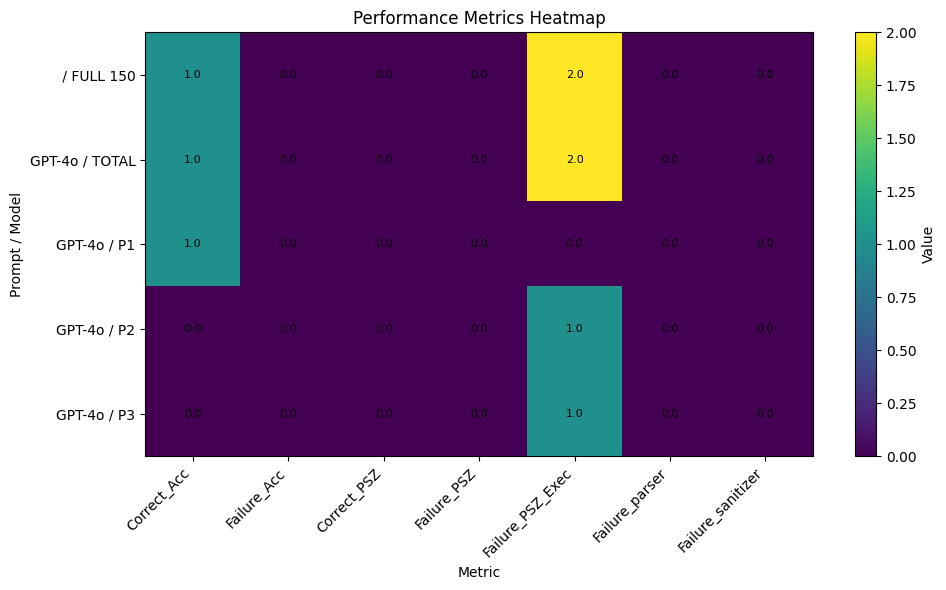

In [56]:
# Matplotlib-only heatmap (no seaborn required).
# This defines a helper function that takes your `summary_table`
# and renders a heatmap with hierarchical index labels.
# If `summary_table` isn't in your environment yet, this will just
# define the function and print a short note.

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_heatmap_matplotlib(summary_table: pd.DataFrame, title: str = "Performance Metrics Heatmap"):
    """
    Plot a heatmap using pure matplotlib.
    Expects the same `summary_table` your code produces.
    - Drops the ("", "FULL 120") row if present.
    - Combines MultiIndex (Prompt, Model) into one readable label.
    - Annotates each cell with its numeric value.
    """
    # Drop the totals row if present
    heatmap_df = summary_table.drop(("", "FULL 120"), errors="ignore").copy()

    # Ensure numeric values (coerce any non-numeric to NaN)
    for col in heatmap_df.columns:
        heatmap_df[col] = pd.to_numeric(heatmap_df[col], errors="coerce")
    values = heatmap_df.to_numpy(dtype=float)

    # Build y-axis labels from MultiIndex: "P# / Model"
    if isinstance(heatmap_df.index, pd.MultiIndex) and heatmap_df.index.nlevels == 2:
        ylabels = [f"{p} / {m}" for p, m in heatmap_df.index.to_list()]
    else:
        ylabels = [str(i) for i in heatmap_df.index.to_list()]

    xlabels = [str(c) for c in heatmap_df.columns.to_list()]

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Show the heatmap; do not set explicit colormap or styles
    im = ax.imshow(values, aspect="auto")

    # Color bar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Value")

    # Ticks and labels
    ax.set_xticks(np.arange(values.shape[1]))
    ax.set_xticklabels(xlabels, rotation=45, ha="right")
    ax.set_yticks(np.arange(values.shape[0]))
    ax.set_yticklabels(ylabels)

    ax.set_xlabel("Metric")
    ax.set_ylabel("Prompt / Model")
    ax.set_title(title)

    # Annotate each cell with the value
    # Use a fixed small font size; no custom colors
    nrows, ncols = values.shape
    for i in range(nrows):
        for j in range(ncols):
            val = values[i, j]
            if np.isnan(val):
                text_str = ""
            else:
                # format with 1 decimal place like your seaborn example
                text_str = f"{val:.1f}"
            ax.text(j, i, text_str, ha="center", va="center", fontsize=8)

    fig.tight_layout()
    plt.show()

# Auto-run if `summary_table` exists in the notebook session
if "summary_table" in globals():
    plot_heatmap_matplotlib(summary_table)
else:
    print("Defined plot_heatmap_matplotlib(). Run it after you create `summary_table`.")


In [58]:
# pd.set_option('display.max_colwidth', None)
# accuracy_df.iloc[[np.floor(num) for num in (np.random.rand(5)*150)]]
# display(accuracy_df.head())

In [59]:
# data = '150_scripts_5_models_sani.pkl'
# accuracy_df_old = pd.read_pickle(f'../../lammps_parser_clone/bin/{data}')
data = 'accuracy_df_trees.pkl'
accuracy_df = pd.read_pickle(data)
print(len(accuracy_df))

3


In [61]:
# analysis_df = accuracy_df[accuracy_df['prompt']=='prompt3'].copy()
analysis_df = accuracy_df.copy()

total_scripts = len(analysis_df)

#Sanitizer 
sanitizer_to_parser = analysis_df['sanitized'].value_counts()[True]
sanitizer_to_failure = total_scripts - analysis_df['sanitized'].value_counts()[True]

#Parser
parser_to_execution = analysis_df['parsed'].value_counts()[True]
parser_to_failure = total_scripts - analysis_df['parsed'].value_counts()[True] - len(analysis_df[analysis_df['sanitized'] != True])
print('Total_scripts: ',total_scripts)
print('Parsed: ',analysis_df['parsed'].value_counts()[True]) 
print('Failed Sanitizer: ',len(analysis_df[analysis_df['sanitized'] != True]))

try:
    execution_to_accuracy = analysis_df['run'].value_counts()[True] #+ analysis_df['pair_run'].value_counts()[True]
except:
    execution_to_accuracy = 0

execution_to_pairstylecheck = 0
for row in analysis_df["run"]:
    if row != True and row != 'not parsed':
#         print(row)
        if ast.literal_eval(row)[1].startswith("Last command:"):
            execution_to_pairstylecheck += 1
print(execution_to_pairstylecheck)

try:
    pairstylecheck_to_execution = analysis_df['pair_run'].value_counts()[True]
except:
    pairstylecheck_to_execution = 0
try:
    execution_to_accuracy_after_pairstyle = analysis_df['pair_run'].value_counts()[True] # not always
except:
    execution_to_accuracy_after_pairstyle = 0
execution_to_failure = total_scripts - execution_to_accuracy - execution_to_accuracy_after_pairstyle - parser_to_failure
try:
    accuracy_to_correct = analysis_df[analysis_df['run']==True]['accurate'].value_counts()[True]
except:
    accuracy_to_correct = 0
    
accuracy_to_failure = execution_to_accuracy - accuracy_to_correct

df = analysis_df[analysis_df['pair_run']==True].copy()
pair_to_accuracy_total = len(df)
print('Total pair True:',pair_to_accuracy_total)

# allowed = {"pair_style", "run_trial", "size10_conflict"}
allowed = {"PSZ", "pair_style inaccurate"}

col = df["accurate"].astype(str)

# rows containing ANY token not in `allowed`
mask_has_disallowed = col.apply(
    lambda s: any(tok not in allowed for tok in map(str.strip, s.split(",")) if tok.strip())
)

bad_count = int(mask_has_disallowed.sum())
# print("Rows with disallowed phrases:", bad_count)

pair_accuracy_to_failure = bad_count
pair_accuracy_to_correct = pair_to_accuracy_total - pair_accuracy_to_failure


print('Accurate Pair Correct: ',pair_accuracy_to_correct)
print('Accurate Pair Failure: ',pair_accuracy_to_failure)

Total_scripts:  3
Parsed:  3
Failed Sanitizer:  0
2
Total pair True: 0
Accurate Pair Correct:  0
Accurate Pair Failure:  0


In [62]:
accuracy_df

,prompt,model,trial,sanitized,parsed,ast_path,run,pair_run,accurate
0,prompt1,gpt-4o,0,True,True,asts/prompt1/gpt-4o/prompt1-gpt-4o-T0.ast.pkl,True,n/a,True
1,prompt2,gpt-4o,0,True,True,asts/prompt2/gpt-4o/prompt2-gpt-4o-T0.ast.pkl,"['ERROR: Incorrect args for pair coefficients (src/src/MANYBODY/pair_eam.cpp:374)', 'Last command: pair_coeff * * potentials/prompt2.potential Ni']",[Errno 2] No such file or directory: '/apps/share64/debian10/lammps/lammps-02Aug23/bin/lmp_serial',"pair_style inaccurate, size"
2,prompt3,gpt-4o,0,True,True,asts/prompt3/gpt-4o/prompt3-gpt-4o-T0.ast.pkl,"['ERROR: Incorrect args for pair coefficients (src/src/MANYBODY/pair_eam.cpp:374)', 'Last command: pair_coeff * * potentials/prompt3.potential Nb Nb']",[Errno 2] No such file or directory: '/apps/share64/debian10/lammps/lammps-02Aug23/bin/lmp_serial',"box_region_missing, fixed bounds, gap_size, pair_style inaccurate, projectile_region_size, run num inaccurate, sim time1 inaccurate, target_region_size, v_set_direction"


In [63]:
accuracy_df[accuracy_df['pair_run']==True]['accurate']# .value_counts()

Series([], Name: accurate, dtype: object)

In [66]:
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15, thickness=40,

        label=[
            "Normalization",      # 0 
            "Parser",         # 1
            "Execution",      # 2
            "Accuracy",       # 3
            "",        # 4
            "PSZ",            # 5
            "Acc.",           # 6
            "",               # 7
            "",               # 8
            "",               # 9
            "",               # 10
            "",               # 11
            "",               # 12
        ],
        x=[
            0.0,  # 0 Sanitizer
            0.2,  # 1 Parser
            0.4, # 2 Execution
            0.75,  # 3 Accuracy
            0.95,  # 4 Correct
            0.6,  # 5 PairStyle0
            0.75, # 6 Accuracy (from PairStyle0)
            0.1,  # 7 Failure (Sanitizer)
            0.3,  # 8 Failure (Parser)
            0.7,  # 9 Failure (Exec from PairStyle0)
            0.85,  #10 Failure (Accuracy)
            0.9,  #11 Failure (Accuracy from Pair0)
            0.9,  #12 Correct (from PairStyle0)
        ],
        y=[
            0.5,  # 0 Sanitizer
            0.4,  # 1 Parser
            0.4,  # 2 Execution
            0.15,  # 3 Accuracy
            0.15,  # 4 Correct
            0.6,  # 5 PairStyle0
            0.5,  # 6 Accuracy (from PairStyle0)
            0.9,  # 7 Failure (Sanitizer)
            0.9,  # 8 Failure (Parser)
            0.9,  # 9 Failure (Exec from PairStyle0)
            0.3,  #10 Failure (Accuracy)
            0.7,  #11 Failure (Accuracy from Pair0)
            0.5,  #12 Correct (from PairStyle0)
        ],
        color=[
            "black", "black", "black", "black", "black",  # 0–4
            "black", "black", "black", "black", "black",# 5–9
            "black", "black", "black", "black", # 10-13
        ]
    ),
    link=dict(
        source=[
            0,  # Sanitizer → Parser
            0,  # Sanitizer → Failure (Sanitizer)
            1,  # Parser → Execution
            1,  # Parser → Failure (Parser)
            2,  # Execution → Accuracy
            2,  # Execution → PairStyle0 (PSZ)
            5,  # PairStyle0 (PSZ) → Accuracy (from PairStyle0)
            5,  # PairStyle0 (PSZ) → Failure (Exec from PairStyle0)
            3,  # Accuracy → Correct
            3,  # Accuracy → Failure (Accuracy)
            6,  # Accuracy (from PairStyle0) → Correct (from PairStyle0)
            6,  # Accuracy (from PairStyle0) → Failure (Accuracy from PairStyle0)
        ],
        target=[
            1,   # Sanitizer → Parser
            7,   # Sanitizer → Failure (Sanitizer)
            2,   # Parser → Execution
            8,   # Parser → Failure (Parser)
            3,   # Execution → Accuracy
            5,   # Execution → PairStyle0 (PSZ)
            6,   # PairStyle0 (PSZ) → Accuracy (from PairStyle0)
            9,   # PairStyle0 (PSZ) → Failure (Exec from PairStyle0)
            4,   # Accuracy → Correct
            10,  # Accuracy → Failure (Accuracy)
            12,  # Accuracy (from PairStyle0) → Correct (from PairStyle0)
            11,  # Accuracy (from PairStyle0) → Failure (Accuracy from PairStyle0)
        ],
        value=[
            sanitizer_to_parser,
            sanitizer_to_failure,
            parser_to_execution,  # Parser → Execution
            parser_to_failure,  # Parser → Execution
            execution_to_accuracy,  # Execution → Accuracy
            execution_to_pairstylecheck, #pairstylecheck_to_execution,  # PairStyle0 → Execution (from PairStyle0)
            execution_to_accuracy_after_pairstyle,  # Execution (from PairStyle0) → Accuracy (from PairStyle0)
            execution_to_pairstylecheck-execution_to_accuracy_after_pairstyle,  # Execution (from PairStyle0) → Failure (Exec from PairStyle0)
            accuracy_to_correct,  # Accuracy → Correct
            accuracy_to_failure,  # Accuracy → Failure (Accuracy)
            pair_accuracy_to_correct,   # Accuracy (from PairStyle0) → Correct (from PairStyle0)
            execution_to_accuracy_after_pairstyle - pair_accuracy_to_correct,    # Accuracy (from PairStyle0) → Failure (Accuracy from PairStyle0)

        ],
        color=[
            "rgba(34, 139, 34, 0.4)",   # Sanitizer → Parser
            "rgba(178, 34, 34, 0.4)",   # Sanitizer → Failure (Sanit)
            "rgba(34, 139, 34, 0.4)",   # Parser → Execution
            "rgba(178, 34, 34, 0.4)",   # Parser → Failure
            "rgba(34, 139, 34, 0.4)",   # Execution → Accuracy
            "rgba(218, 165, 32, 0.4)",  # PairStyle0 → Execution (retry)
            "rgba(34, 139, 34, 0.4)",   # Retry → Accuracy (PairStyle0)
            "rgba(178, 34, 34, 0.4)",   # Retry → Failure (PairStyle0 Exec)
            "rgba(34, 139, 34, 0.4)",   # Accuracy → Correct
            "rgba(178, 34, 34, 0.4)",   # Accuracy → Failure
            "rgba(126, 152, 33, 0.4)",  # Accuracy (from PairStyle0) → Correct (yellow)
            "rgba(178, 34, 34, 0.4)",   # Accuracy (from PairStyle0) → Failure
        ]
    )
))

# fig.update_traces(
#     arrangement="fixed"
# )

fig.show()

In [67]:
from IPython.display import HTML, display

display(HTML("""
<script>
(function () {
  const root = document.querySelector('.js-plotly-plot');
  if (!root) return;
  // ---- Font sizing controls ----
  const FS_MIN = 14;   // px (floor)
  const FS_MAX = 30;   // px (cap)
  const FS_K   = 0.12; // scale factor (px font per px bar height)
  // NEW: inset (px) for placing numbers just outside the edge
  const INSET = 6;

  function parseBase(transformStr) {
    const m = /translate\\(\\s*([-+]?\\d*\\.?\\d+)\\s*,\\s*([-+]?\\d*\\.?\\d+)\\s*\\)/.exec(transformStr || "");
    return { x: m ? parseFloat(m[1]) || 0 : 0, y: m ? parseFloat(m[2]) || 0 : 0 };
  }

  // number formatter
  const fmt = new Intl.NumberFormat(undefined, { maximumFractionDigits: 0 });

  function placeLabels() {
    const nodes = root.querySelectorAll('g.sankey g.sankey-node-set g.sankey-node');
    // compute node totals (max(in, out)) from the plotted trace
    let tot = [];
    const tr = (root._fullData || []).find(t => t.type === 'sankey');
    if (tr) {
      const n = tr.node.label.length;
      const inTot  = Array(n).fill(0);
      const outTot = Array(n).fill(0);
      const S = tr.link.source || [];
      const T = tr.link.target || [];
      const V = tr.link.value  || [];
      for (let i = 0; i < V.length; i++) {
        outTot[S[i]] += +V[i] || 0;
        inTot[T[i]]  += +V[i] || 0;
      }
      tot = inTot.map((v,i) => Math.max(v, outTot[i]));
    }

    nodes.forEach((node, i) => {
      const rect  = node.querySelector('rect.node-rect');
      const label = node.querySelector('text.node-label');
      if (!rect || !label) return;

      const w = parseFloat(rect.getAttribute('width'))  || 0;
      const h = parseFloat(rect.getAttribute('height')) || 0;

      // --- Scaled & capped font size ---
      let fontSize = Math.round(h * FS_K);
      if (!isFinite(fontSize)) fontSize = FS_MIN;
      fontSize = Math.max(FS_MIN, Math.min(FS_MAX, fontSize));

      // Preserve original side/transform from first run
      const origAnchor    = label.dataset.origAnchor    || label.getAttribute('text-anchor') || 'start';
      const origTransform = label.dataset.origTransform || (label.getAttribute('transform') || '');
      label.dataset.origAnchor = origAnchor;
      label.dataset.origTransform = origTransform;

      // Style the rotated label (white) – stays centered inside bar
      label.style.fill = '#fff';
      label.style.fontWeight = '700';
      label.style.fontSize = fontSize + 'px';
      label.style.textShadow = 'none';
      label.style.writingMode = 'sideways-lr';   // vertical, preserves Plotly's translate(x, midY)
      label.style.textOrientation = 'mixed';
      label.style.textRendering = 'geometricPrecision';
      label.style.webkitFontSmoothing = 'antialiased';
      label.style.MozOsxFontSmoothing = 'grayscale';
      label.setAttribute('text-anchor', 'middle');
      label.setAttribute('dominant-baseline', 'middle');

      // Keep Plotly's mid-Y; shift X to bar center — based on the ORIGINAL transform
      const {x: x0} = parseBase(origTransform);
      const xTarget = w / 2;
      const dxCenter = Math.round(xTarget - x0);  // snap to integer px to avoid blur
      label.setAttribute('transform', origTransform + ` translate(${dxCenter},0)`);

      // --- Number on the LEFT side of the bar (black, not rotated) ---
      let vtext = node.querySelector('text.__nodeval');
      if (!vtext) {
        vtext = document.createElementNS('http://www.w3.org/2000/svg','text');
        vtext.setAttribute('class','__nodeval');
        node.appendChild(vtext);
      }
      const valSize = Math.max(12, Math.min(22, fontSize));

      // ---- MODIFIED SECTION ----
      // Always place the number on the LEFT of the bar.
      // To do this, we right-align the text ('end' anchor) and place it just to the left of the bar's origin.
      vtext.setAttribute('text-anchor', 'end'); // Use 'end' to right-align the text
      vtext.setAttribute('dominant-baseline', 'middle');
      vtext.setAttribute('style',
        `font-size:${valSize}px;font-weight:700;fill:#000;text-shadow:none;pointer-events:none;writing-mode:initial;text-orientation:mixed;`);

      // Compute target x on the left side relative to the node's local coords
      const desiredX = -INSET; // Position is always -INSET (just left of the bar)
      const dxOther  = Math.round(desiredX - x0);
      
      // Position number at same mid-Y as original, but on the left side in X
      vtext.setAttribute('transform', origTransform + ` translate(${dxOther},0)`);

      // Content
      const val = (tot && Number.isFinite(tot[i])) ? tot[i] : 0;
      vtext.textContent = fmt.format(val);
    });
  }

  if (root.on) {
    root.on('plotly_afterplot', placeLabels);
    root.on('plotly_relayout',  placeLabels);
    root.on('plotly_animated',  placeLabels);
  }
  placeLabels();
})();
</script>
"""))

# Individual Breakdowns

In [68]:
df_p1_gpt4o = get_accuracy_df("prompt3", "gpt-4o", accuracy_df, prompt_model_map1)
metrics_choice = compute_accuracy_metrics(df_p1_gpt4o)
display(metrics_choice)


{'total_scripts': 1,
 'sanitizer_to_parser': 1,
 'sanitizer_to_failure': 0,
 'parser_to_execution': 1,
 'parser_to_failure': 0,
 'execution_to_accuracy': 0,
 'execution_to_pairstylecheck': 1,
 'pairstylecheck_to_execution': 0,
 'execution_to_accuracy_after_pairstyle': 0,
 'execution_to_failure': 1,
 'accuracy_to_correct': 0,
 'accuracy_to_failure': 0,
 'pair_accuracy_to_correct': 0}

In [69]:
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15, thickness=40,

        label=[
            "Sanitizer",      # 0 
            "Parser",         # 1
            "Execution",      # 2
            "Accuracy",       # 3
            "",        # 4
            "PSZ",            # 5
            "Acc.",           # 6
            "",               # 7
            "",               # 8
            "",               # 9
            "",               # 10
            "",               # 11
            "",               # 12
        ],
        x=[
            0.0,  # 0 Sanitizer
            0.2,  # 1 Parser
            0.4, # 2 Execution
            0.75,  # 3 Accuracy
            0.95,  # 4 Correct
            0.6,  # 5 PairStyle0
            0.75, # 6 Accuracy (from PairStyle0)
            0.1,  # 7 Failure (Sanitizer)
            0.3,  # 8 Failure (Parser)
            0.7,  # 9 Failure (Exec from PairStyle0)
            0.85,  #10 Failure (Accuracy)
            0.9,  #11 Failure (Accuracy from Pair0)
            0.9,  #12 Correct (from PairStyle0)
        ],
        y=[
            0.5,  # 0 Sanitizer
            0.4,  # 1 Parser
            0.4,  # 2 Execution
            0.15,  # 3 Accuracy
            0.15,  # 4 Correct
            0.6,  # 5 PairStyle0
            0.5,  # 6 Accuracy (from PairStyle0)
            0.9,  # 7 Failure (Sanitizer)
            0.9,  # 8 Failure (Parser)
            0.9,  # 9 Failure (Exec from PairStyle0)
            0.3,  #10 Failure (Accuracy)
            0.7,  #11 Failure (Accuracy from Pair0)
            0.5,  #12 Correct (from PairStyle0)
        ],
        color=[
            "black", "black", "black", "black", "black",  # 0–4
            "black", "black", "black", "black", "black",# 5–9
            "black", "black", "black", "black", # 10-13
        ]
    ),
    link=dict(
        source=[
            0,  # Sanitizer → Parser
            0,  # Sanitizer → Failure (Sanitizer)
            1,  # Parser → Execution
            1,  # Parser → Failure (Parser)
            2,  # Execution → Accuracy
            2,  # Execution → PairStyle0 (PSZ)
            5,  # PairStyle0 (PSZ) → Accuracy (from PairStyle0)
            5,  # PairStyle0 (PSZ) → Failure (Exec from PairStyle0)
            3,  # Accuracy → Correct
            3,  # Accuracy → Failure (Accuracy)
            6,  # Accuracy (from PairStyle0) → Correct (from PairStyle0)
            6,  # Accuracy (from PairStyle0) → Failure (Accuracy from PairStyle0)
        ],
        target=[
            1,   # Sanitizer → Parser
            7,   # Sanitizer → Failure (Sanitizer)
            2,   # Parser → Execution
            8,   # Parser → Failure (Parser)
            3,   # Execution → Accuracy
            5,   # Execution → PairStyle0 (PSZ)
            6,   # PairStyle0 (PSZ) → Accuracy (from PairStyle0)
            9,   # PairStyle0 (PSZ) → Failure (Exec from PairStyle0)
            4,   # Accuracy → Correct
            10,  # Accuracy → Failure (Accuracy)
            12,  # Accuracy (from PairStyle0) → Correct (from PairStyle0)
            11,  # Accuracy (from PairStyle0) → Failure (Accuracy from PairStyle0)
        ],
        value=[
            metrics_choice['sanitizer_to_parser'],
            metrics_choice['sanitizer_to_failure'],
            metrics_choice['parser_to_execution'],  # Parser → Execution
            metrics_choice['parser_to_failure'],  # Parser → Execution
            metrics_choice['execution_to_accuracy'],  # Execution → Accuracy
            metrics_choice['execution_to_pairstylecheck'], #pairstylecheck_to_execution,  # PairStyle0 → Execution (from PairStyle0)
            metrics_choice['execution_to_accuracy_after_pairstyle'],  # Execution (from PairStyle0) → Accuracy (from PairStyle0)
            metrics_choice['execution_to_pairstylecheck'] - metrics_choice['execution_to_accuracy_after_pairstyle'],  # Execution (from PairStyle0) → Failure (Exec from PairStyle0)
            metrics_choice['accuracy_to_correct'],  # Accuracy → Correct
            metrics_choice['accuracy_to_failure'],  # Accuracy → Failure (Accuracy)
            metrics_choice['pair_accuracy_to_correct'],   # Accuracy (from PairStyle0) → Correct (from PairStyle0)
            metrics_choice['execution_to_accuracy_after_pairstyle'] - metrics_choice['pair_accuracy_to_correct'],    # Accuracy (from PairStyle0) → Failure (Accuracy from PairStyle0)

        ],
        color=[
            "rgba(34, 139, 34, 0.4)",   # Sanitizer → Parser
            "rgba(178, 34, 34, 0.4)",   # Sanitizer → Failure (Sanit)
            "rgba(34, 139, 34, 0.4)",   # Parser → Execution
            "rgba(178, 34, 34, 0.4)",   # Parser → Failure
            "rgba(34, 139, 34, 0.4)",   # Execution → Accuracy
            "rgba(218, 165, 32, 0.4)",  # PairStyle0 → Execution (retry)
            "rgba(34, 139, 34, 0.4)",   # Retry → Accuracy (PairStyle0)
            "rgba(178, 34, 34, 0.4)",   # Retry → Failure (PairStyle0 Exec)
            "rgba(34, 139, 34, 0.4)",   # Accuracy → Correct
            "rgba(178, 34, 34, 0.4)",   # Accuracy → Failure
            "rgba(218, 165, 32, 0.4)",  # Accuracy (from PairStyle0) → Correct (yellow)
            "rgba(178, 34, 34, 0.4)",   # Accuracy (from PairStyle0) → Failure
        ]
    )
))

# fig.update_traces(
#     arrangement="fixed"
# )

fig.show()